In [2]:
import pandas as pd

train = pd.read_csv("/kaggle/input/competitions/llm-classification-finetuning/train.csv")
test = pd.read_csv("/kaggle/input/competitions/llm-classification-finetuning/test.csv")
sample = pd.read_csv("/kaggle/input/competitions/llm-classification-finetuning/sample_submission.csv")

print(train.shape)
print(test.shape)
train.head()

(57477, 9)
(3, 4)


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1
3,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0
4,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57477 entries, 0 to 57476
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              57477 non-null  int64 
 1   model_a         57477 non-null  object
 2   model_b         57477 non-null  object
 3   prompt          57477 non-null  object
 4   response_a      57477 non-null  object
 5   response_b      57477 non-null  object
 6   winner_model_a  57477 non-null  int64 
 7   winner_model_b  57477 non-null  int64 
 8   winner_tie      57477 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 3.9+ MB


In [4]:
train.columns

Index(['id', 'model_a', 'model_b', 'prompt', 'response_a', 'response_b',
       'winner_model_a', 'winner_model_b', 'winner_tie'],
      dtype='object')

In [5]:
train["label"] = (
    train["winner_model_b"] * 1 +
    train["winner_tie"] * 2
)

train["label"].value_counts()

label
0    20064
1    19652
2    17761
Name: count, dtype: int64

In [6]:
train.iloc[0]["prompt"]
train.iloc[0]["response_b"][:800]

'["As an AI, I don\'t have personal beliefs or opinions. However, I can tell you that the question of gender quotas in managerial positions is a complex one and positions can vary. Advocates argue that such measures can help correct historical imbalances, promote diversity, and may lead to better decision-making. Critics may argue that positions should be based purely on merit, and that quotas could potentially lead to tokenism or unqualified candidates being promoted. Morality can be subjective and differs from person to person based on their personal beliefs, cultural background, and values. It\'s a topic with valid arguments on both sides, and it\'s up to each individual or organization to decide what they believe is right.","As an AI, I don\'t eat, so I don\'t have personal preferences. But,'

In [7]:
train["prompt"].str.len().describe()

count    57477.000000
mean       369.198584
std       1073.341472
min          7.000000
25%         52.000000
50%         96.000000
75%        243.000000
max      33056.000000
Name: prompt, dtype: float64

In [8]:
import pandas as pd

train["prompt_len"] = train["prompt"].str.len()
train["response_a_len"] = train["response_a"].str.len()
train["response_b_len"] = train["response_b"].str.len()

train[[
    "prompt_len",
    "response_a_len",
    "response_b_len"
]].describe()

,prompt_len,response_a_len,response_b_len
count,57477.000000,57477.000000,57477.000000
mean,369.198584,1377.818919,1386.162169
std,1073.341472,1513.932333,1537.800488
min,7.000000,4.000000,4.000000
25%,52.000000,408.000000,413.000000
50%,96.000000,1076.000000,1086.000000
75%,243.000000,1862.000000,1873.000000
max,33056.000000,54058.000000,53830.000000


array([[<Axes: title={'center': 'prompt_len'}>,
        <Axes: title={'center': 'response_a_len'}>],
       [<Axes: title={'center': 'response_b_len'}>, <Axes: >]],
      dtype=object)

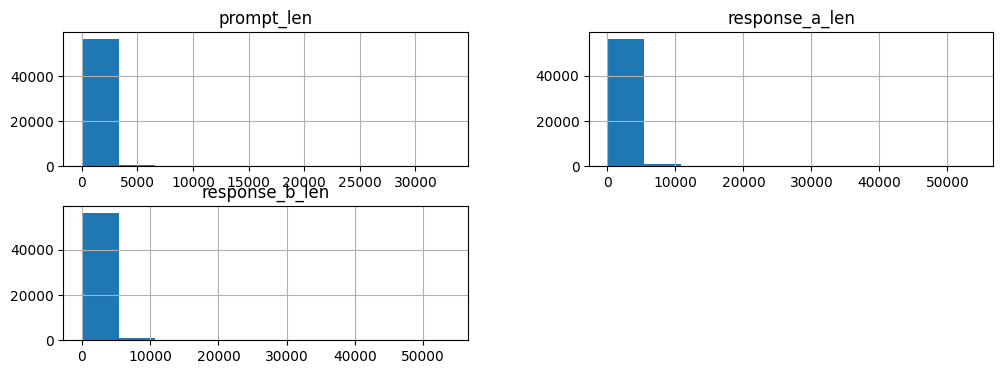

In [9]:
train[[
    "prompt_len",
    "response_a_len",
    "response_b_len"
]].hist(figsize=(12,4))


array([[<Axes: title={'center': 'prompt_len'}>,
        <Axes: title={'center': 'response_a_len'}>],
       [<Axes: title={'center': 'response_b_len'}>, <Axes: >]],
      dtype=object)

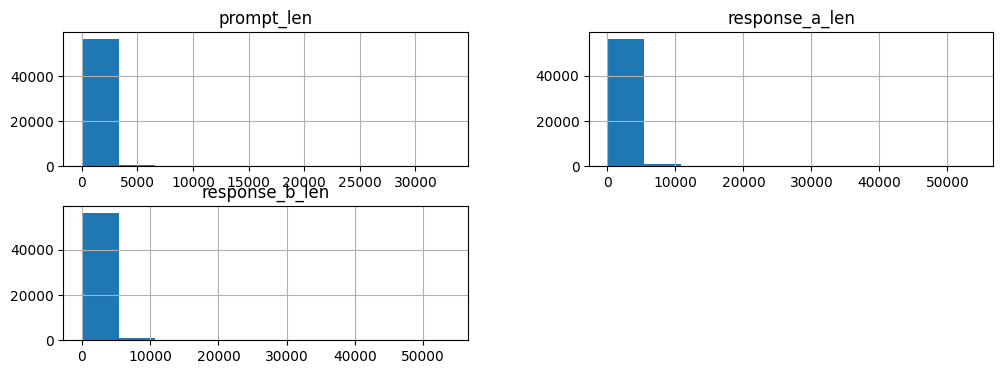

In [10]:
train[[
    "prompt_len",
    "response_a_len",
    "response_b_len"
]].describe()
train[[
    "prompt_len",
    "response_a_len",
    "response_b_len"
]].hist(figsize=(12,4))

In [11]:
train["same_model"] = train["model_a"] == train["model_b"]

train["same_model"].value_counts()
train["model_a"].value_counts().head(20)
train["model_b"].value_counts().head(20)

model_b
gpt-4-1106-preview            3709
gpt-3.5-turbo-0613            3530
gpt-4-0613                    3066
claude-2.1                    2724
claude-instant-1              2051
gpt-4-0314                    2035
claude-1                      2023
vicuna-33b                    1877
mixtral-8x7b-instruct-v0.1    1804
llama-2-70b-chat              1753
vicuna-13b                    1743
gpt-3.5-turbo-1106            1666
mistral-medium                1609
llama-2-13b-chat              1331
zephyr-7b-beta                1194
claude-2.0                    1184
palm-2                         958
llama-2-7b-chat                937
wizardlm-70b                   844
vicuna-7b                      826
Name: count, dtype: int64

In [12]:
import ast
def parse_text(x):
    try:
        return "\n".join(ast.literal_eval(x))
    except:
        return str(x)

In [13]:
# ============================================================
# STEP 1: Imports, configuration, and reproducibility
# ============================================================

import os
import random
import warnings

import numpy as np
import pandas as pd

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
warnings.filterwarnings("ignore")

print(f"Setup completed successfully | Random seed: {SEED}")

Setup completed successfully | Random seed: 42


In [16]:
# ============================================================
# STEP 2: Load competition datasets
# ============================================================

DATA_DIR = "/kaggle/input/competitions/llm-classification-finetuning/train.csv"

train_path = os.path.join(DATA_DIR, "/kaggle/input/competitions/llm-classification-finetuning/train.csv")
test_path = os.path.join(DATA_DIR, "/kaggle/input/competitions/llm-classification-finetuning/test.csv")
sample_path = os.path.join(DATA_DIR, "/kaggle/input/competitions/llm-classification-finetuning/sample_submission.csv")

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample_submission = pd.read_csv("/kaggle/input/competitions/llm-classification-finetuning/sample_submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample submission shape:", sample_submission.shape)

display(train.head(2))

Train shape: (57477, 9)
Test shape: (3, 4)
Sample submission shape: (3, 4)


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain percentage of females on managerial positions?"",""OK, does pineapple b...","[""The question of whether it is morally right to aim for a certain percentage of females in managerial positions is ...","[""As an AI, I don't have personal beliefs or opinions. However, I can tell you that the question of gender quotas in...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage license and marriage certificate?"",""How can I get both of them as quick as...","[""A marriage license is a legal document that allows a couple to get married. It is issued by a government agency, s...","[""A marriage license and a marriage certificate are two different legal documents that have separate purposes.\n\n1....",0,1,0


In [17]:
# ============================================================
# STEP 3: Inspect structure and validate basic data integrity
# ============================================================

TARGET_COLUMNS = [
    "winner_model_a",
    "winner_model_b",
    "winner_tie",
]

print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

print("\nMissing values in train:")
display(train.isna().sum().to_frame("missing_count"))

print("Duplicate train IDs:", train["id"].duplicated().sum())
print("Duplicate test IDs:", test["id"].duplicated().sum())

target_sum = train[TARGET_COLUMNS].sum(axis=1)
print("Rows with invalid target:", (target_sum != 1).sum())

Train columns:
['id', 'model_a', 'model_b', 'prompt', 'response_a', 'response_b', 'winner_model_a', 'winner_model_b', 'winner_tie']

Test columns:
['id', 'prompt', 'response_a', 'response_b']

Missing values in train:


,missing_count
id,0
model_a,0
model_b,0
prompt,0
response_a,0
response_b,0
winner_model_a,0
winner_model_b,0
winner_tie,0


Duplicate train IDs: 0
Duplicate test IDs: 0
Rows with invalid target: 0


In [18]:
# ============================================================
# STEP 4: Parse stringified conversation lists
# ============================================================

import ast

TEXT_COLUMNS = ["prompt", "response_a", "response_b"]

def parse_conversation(value):
    try:
        parsed = ast.literal_eval(value)

        if isinstance(parsed, list):
            return "\n".join(str(item) for item in parsed)

        return str(parsed)

    except (ValueError, SyntaxError, TypeError):
        return str(value)

for column in TEXT_COLUMNS:
    train[column + "_clean"] = train[column].apply(parse_conversation)
    test[column + "_clean"] = test[column].apply(parse_conversation)

display(train[["prompt", "prompt_clean"]].head(2))

,prompt,prompt_clean
0,"[""Is it morally right to try to have a certain percentage of females on managerial positions?"",""OK, does pineapple b...","Is it morally right to try to have a certain percentage of females on managerial positions?\nOK, does pineapple belo..."
1,"[""What is the difference between marriage license and marriage certificate?"",""How can I get both of them as quick as...",What is the difference between marriage license and marriage certificate?\nHow can I get both of them as quick as po...


In [19]:
# ============================================================
# STEP 5: Create a single target label
# ============================================================

LABEL_NAMES = {
    0: "winner_model_a",
    1: "winner_model_b",
    2: "winner_tie",
}

train["label"] = (
    train[TARGET_COLUMNS]
    .to_numpy()
    .argmax(axis=1)
)

class_counts = train["label"].value_counts().sort_index()
class_percent = train["label"].value_counts(
    normalize=True
).sort_index() * 100

class_summary = pd.DataFrame({
    "class_name": [LABEL_NAMES[i] for i in class_counts.index],
    "count": class_counts.values,
    "percentage": class_percent.round(2).values,
})

display(class_summary)

,class_name,count,percentage
0,winner_model_a,20064,34.91
1,winner_model_b,19652,34.19
2,winner_tie,17761,30.90


In [21]:
# ============================================================
# STEP 6: Analyze cleaned text lengths
# ============================================================

CLEAN_TEXT_COLUMNS = [
    "prompt_clean",
    "response_a_clean",
    "response_b_clean",
]

for column in CLEAN_TEXT_COLUMNS:
    train[column + "_chars"] = train[column].str.len()
    train[column + "_words"] = train[column].str.split().str.len()

length_summary = train[
    [column + "_chars" for column in CLEAN_TEXT_COLUMNS]
].describe(percentiles=[0.50, 0.75, 0.90, 0.95]).T

length_summary = length_summary[
    ["mean", "50%", "75%", "90%", "95%", "max"]
].round(1)

display(length_summary)

,mean,50%,75%,90%,95%,max
prompt_clean_chars,352.8,91.0,234.0,758.0,1421.0,32839.0
response_a_clean_chars,1331.6,1037.0,1811.0,2706.0,3585.4,53299.0
response_b_clean_chars,1338.5,1045.0,1820.0,2698.0,3579.2,52403.0


In [25]:
# ============================================================
# STEP 7: Check repeated prompts and exact duplicate pairs
# ============================================================

import hashlib

def make_hash(text):
    safe_text = str(text).encode(
        "utf-8",
        errors="replace"
    )
    return hashlib.sha256(safe_text).hexdigest()

train["prompt_hash"] = train["prompt_clean"].apply(make_hash)

pair_text = (
    train["prompt_clean"] + "\n[RESPONSE_A]\n"
    + train["response_a_clean"] + "\n[RESPONSE_B]\n"
    + train["response_b_clean"]
)

train["pair_hash"] = pair_text.apply(make_hash)
prompt_counts = train["prompt_hash"].value_counts()

print("Total rows:", len(train))
print("Unique prompts:", train["prompt_hash"].nunique())
print("Repeated prompt groups:", (prompt_counts > 1).sum())
print("Rows in repeated prompts:",
      train["prompt_hash"].duplicated(keep=False).sum())
print("Exact duplicate comparisons:",
      train["pair_hash"].duplicated().sum())

Total rows: 57477
Unique prompts: 51733
Repeated prompt groups: 3119
Rows in repeated prompts: 8863
Exact duplicate comparisons: 71


In [26]:
# ============================================================
# STEP 8: Create a leakage-safe train-validation split
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold

N_SPLITS = 5

splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED,
)

train_index, valid_index = next(
    splitter.split(
        X=train,
        y=train["label"],
        groups=train["prompt_hash"],
    )
)

train_part = train.iloc[train_index].reset_index(drop=True)
valid_part = train.iloc[valid_index].reset_index(drop=True)

print("Training rows:", len(train_part))
print("Validation rows:", len(valid_part))
print("Shared prompts:", len(
    set(train_part["prompt_hash"]) &
    set(valid_part["prompt_hash"])
))

Training rows: 45945
Validation rows: 11532
Shared prompts: 0


In [27]:
# ============================================================
# STEP 9: Build simple probability baselines
# ============================================================

from sklearn.metrics import log_loss

y_valid = valid_part["label"].to_numpy()

uniform_prob = np.full(
    shape=(len(valid_part), 3),
    fill_value=1 / 3,
)

class_prior = (
    train_part["label"]
    .value_counts(normalize=True)
    .sort_index()
    .to_numpy()
)

prior_prob = np.tile(class_prior, (len(valid_part), 1))

print("Uniform log loss:",
      round(log_loss(y_valid, uniform_prob), 5))
print("Class-prior probabilities:", class_prior.round(4))
print("Class-prior log loss:",
      round(log_loss(y_valid, prior_prob), 5))

Uniform log loss: 1.09861
Class-prior probabilities: [0.3488 0.3406 0.3106]
Class-prior log loss: 1.09662


In [28]:
# ============================================================
# STEP 10: Create simple numeric features
# ============================================================

def create_numeric_features(data):
    features = pd.DataFrame(index=data.index)

    prompt = data["prompt_clean"].fillna("")
    response_a = data["response_a_clean"].fillna("")
    response_b = data["response_b_clean"].fillna("")

    features["prompt_chars"] = prompt.str.len()
    features["response_a_chars"] = response_a.str.len()
    features["response_b_chars"] = response_b.str.len()

    features["length_difference"] = (
        features["response_a_chars"] - features["response_b_chars"]
    )

    features["length_ratio"] = (
        features["response_a_chars"] + 1
    ) / (features["response_b_chars"] + 1)

    features["a_code_blocks"] = response_a.str.count(r"```")
    features["b_code_blocks"] = response_b.str.count(r"```")

    return features.astype(float)

X_train_numeric = create_numeric_features(train_part)
X_valid_numeric = create_numeric_features(valid_part)

display(X_train_numeric.head())

,prompt_chars,response_a_chars,response_b_chars,length_difference,length_ratio,a_code_blocks,b_code_blocks
0,159.0,4461.0,1200.0,3261.0,3.715237,0.0,0.0
1,56.0,884.0,1796.0,-912.0,0.492487,2.0,4.0
2,83.0,3165.0,1550.0,1615.0,2.041264,0.0,0.0
3,75.0,1290.0,760.0,530.0,1.696452,0.0,0.0
4,239.0,916.0,1932.0,-1016.0,0.474392,0.0,0.0


In [29]:
# ============================================================
# STEP 11: Train the first numeric baseline model
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

numeric_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=SEED
    ))
])

numeric_model.fit(
    X_train_numeric,
    train_part["label"]
)

valid_prob = numeric_model.predict_proba(X_valid_numeric)
valid_pred = valid_prob.argmax(axis=1)

print("Validation log loss:",
      round(log_loss(valid_part["label"], valid_prob), 5))
print("Validation accuracy:",
      round(accuracy_score(valid_part["label"], valid_pred), 5))

Validation log loss: 1.07485
Validation accuracy: 0.43921


In [30]:
# ============================================================
# STEP 12: Build structured pairwise text
# ============================================================

def build_pairwise_text(data):
    combined_text = (
        "[PROMPT]\n"
        + data["prompt_clean"].fillna("")
        + "\n\n[RESPONSE_A]\n"
        + data["response_a_clean"].fillna("")
        + "\n\n[RESPONSE_B]\n"
        + data["response_b_clean"].fillna("")
    )
    return combined_text

train_text = build_pairwise_text(train_part)
valid_text = build_pairwise_text(valid_part)
test_text = build_pairwise_text(test)

print("Training texts:", len(train_text))
print("Validation texts:", len(valid_text))
print("Test texts:", len(test_text))

print("\nExample structured text:\n")
print(train_text.iloc[0][:1500])

Training texts: 45945
Validation texts: 11532
Test texts: 3

Example structured text:

[PROMPT]
Is it morally right to try to have a certain percentage of females on managerial positions?
OK, does pineapple belong on a pizza? Relax and give me fun answer.

[RESPONSE_A]
The question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves considerations of fairness, equality, diversity, and discrimination.

Here are some arguments in favor of and against such policies:

**Arguments in favor:**

1. **Correcting Historical Inequities:** Women have historically been underrepresented in leadership roles due to various cultural, institutional, and social barriers. Aiming for a specific percentage can be seen as a corrective measure to address past and ongoing discrimination.

2. **Promoting Diversity:** Diverse leadership teams can enhance decision-making and represent a broader range of perspectives. This can 

In [31]:
# ============================================================
# STEP 13: Convert text into TF-IDF features
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.98,
    max_features=120000,
    sublinear_tf=True,
    strip_accents="unicode"
)

X_train_tfidf = tfidf.fit_transform(train_text)
X_valid_tfidf = tfidf.transform(valid_text)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_valid_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))

Training TF-IDF shape: (45945, 120000)
Validation TF-IDF shape: (11532, 120000)
Vocabulary size: 120000


In [32]:
# ============================================================
# STEP 14: Train TF-IDF Logistic Regression model
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

tfidf_model = LogisticRegression(
    C=2.0,
    max_iter=1000,
    solver="liblinear",
    random_state=SEED
)

tfidf_model.fit(
    X_train_tfidf,
    train_part["label"]
)

tfidf_valid_prob = tfidf_model.predict_proba(X_valid_tfidf)
tfidf_valid_pred = tfidf_valid_prob.argmax(axis=1)

print("TF-IDF validation log loss:",
      round(log_loss(valid_part["label"], tfidf_valid_prob), 5))
print("TF-IDF validation accuracy:",
      round(accuracy_score(valid_part["label"], tfidf_valid_pred), 5))

TF-IDF validation log loss: 1.10997
TF-IDF validation accuracy: 0.3864


In [33]:
# ============================================================
# STEP 15: Build position-aware TF-IDF features
# ============================================================

from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer

response_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=3,
    max_features=80000,
    sublinear_tf=True,
    strip_accents="unicode"
)

all_train_responses = pd.concat([
    train_part["response_a_clean"],
    train_part["response_b_clean"]
])

response_vectorizer.fit(all_train_responses)

train_a = response_vectorizer.transform(train_part["response_a_clean"])
train_b = response_vectorizer.transform(train_part["response_b_clean"])
valid_a = response_vectorizer.transform(valid_part["response_a_clean"])
valid_b = response_vectorizer.transform(valid_part["response_b_clean"])

X_train_position = hstack([train_a, train_b, train_a - train_b]).tocsr()
X_valid_position = hstack([valid_a, valid_b, valid_a - valid_b]).tocsr()

print("Training feature shape:", X_train_position.shape)
print("Validation feature shape:", X_valid_position.shape)

Training feature shape: (45945, 240000)
Validation feature shape: (11532, 240000)


In [34]:
# ============================================================
# STEP 16: Train position-aware TF-IDF model
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss

position_model = LogisticRegression(
    C=1.0,
    max_iter=1200,
    solver="liblinear",
    random_state=SEED
)

position_model.fit(
    X_train_position,
    train_part["label"]
)

position_valid_prob = position_model.predict_proba(X_valid_position)
position_valid_pred = position_valid_prob.argmax(axis=1)

print("Position-aware log loss:",
      round(log_loss(valid_part["label"], position_valid_prob), 5))
print("Position-aware accuracy:",
      round(accuracy_score(valid_part["label"], position_valid_pred), 5))

Position-aware log loss: 1.08559
Position-aware accuracy: 0.44086


In [35]:
# ============================================================
# STEP 17: Blend numeric and position-aware TF-IDF models
# ============================================================

blend_results = []

for tfidf_weight in np.arange(0.0, 1.01, 0.1):
    numeric_weight = 1.0 - tfidf_weight

    blended_prob = (
        numeric_weight * valid_prob
        + tfidf_weight * position_valid_prob
    )

    score = log_loss(valid_part["label"], blended_prob)
    blend_results.append((tfidf_weight, score))

blend_results = pd.DataFrame(
    blend_results,
    columns=["tfidf_weight", "log_loss"]
)

best_row = blend_results.loc[blend_results["log_loss"].idxmin()]

display(blend_results.round(5))
print("Best TF-IDF weight:", best_row["tfidf_weight"])
print("Best blended log loss:", round(best_row["log_loss"], 5))

,tfidf_weight,log_loss
0,0.0,1.07485
1,0.1,1.06341
2,0.2,1.05637
3,0.3,1.05168
4,0.4,1.04913
5,0.5,1.04867
6,0.6,1.05038
7,0.7,1.05441
8,0.8,1.06109
9,0.9,1.07101


Best TF-IDF weight: 0.5
Best blended log loss: 1.04867


In [36]:
# ============================================================
# STEP 18: Evaluate the best blended model by class
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report

BEST_TFIDF_WEIGHT = 0.5
BEST_NUMERIC_WEIGHT = 1.0 - BEST_TFIDF_WEIGHT

best_blended_prob = (
    BEST_NUMERIC_WEIGHT * valid_prob
    + BEST_TFIDF_WEIGHT * position_valid_prob
)

best_blended_pred = best_blended_prob.argmax(axis=1)

conf_matrix = confusion_matrix(
    valid_part["label"],
    best_blended_pred
)

print("Best blended log loss:",
      round(log_loss(valid_part["label"], best_blended_prob), 5))

print("\nConfusion matrix:")
display(pd.DataFrame(
    conf_matrix,
    index=["Actual A", "Actual B", "Actual Tie"],
    columns=["Predicted A", "Predicted B", "Predicted Tie"]
))

print(classification_report(
    valid_part["label"],
    best_blended_pred,
    target_names=["A wins", "B wins", "Tie"]
))

Best blended log loss: 1.04867

Confusion matrix:


,Predicted A,Predicted B,Predicted Tie
Actual A,2177,1162,701
Actual B,1165,2117,720
Actual Tie,1268,1266,956


              precision    recall  f1-score   support

      A wins       0.47      0.54      0.50      4040
      B wins       0.47      0.53      0.50      4002
         Tie       0.40      0.27      0.33      3490

    accuracy                           0.46     11532
   macro avg       0.45      0.45      0.44     11532
weighted avg       0.45      0.46      0.45     11532



In [37]:
# ============================================================
# STEP 19: Inspect prediction and probability bias
# ============================================================

actual_distribution = (
    valid_part["label"]
    .value_counts(normalize=True)
    .sort_index()
)

predicted_distribution = pd.Series(
    best_blended_pred
).value_counts(normalize=True).sort_index()

average_probabilities = best_blended_prob.mean(axis=0)

bias_summary = pd.DataFrame({
    "class_name": ["A wins", "B wins", "Tie"],
    "actual_ratio": actual_distribution.reindex([0, 1, 2]).values,
    "predicted_ratio": predicted_distribution.reindex(
        [0, 1, 2], fill_value=0
    ).values,
    "average_probability": average_probabilities
})

bias_summary[[
    "actual_ratio", "predicted_ratio", "average_probability"
]] *= 100

display(bias_summary.round(2))

,class_name,actual_ratio,predicted_ratio,average_probability
0,A wins,35.03,39.98,34.62
1,B wins,34.70,39.41,34.50
2,Tie,30.26,20.61,30.88


In [38]:
# ============================================================
# STEP 20: Tune prediction confidence with temperature scaling
# ============================================================

temperature_results = []

for temperature in np.arange(0.7, 2.01, 0.1):
    scaled_prob = best_blended_prob ** (1.0 / temperature)
    scaled_prob /= scaled_prob.sum(axis=1, keepdims=True)

    score = log_loss(
        valid_part["label"],
        scaled_prob
    )

    temperature_results.append((temperature, score))

temperature_results = pd.DataFrame(
    temperature_results,
    columns=["temperature", "log_loss"]
)

best_temp_row = temperature_results.loc[
    temperature_results["log_loss"].idxmin()
]

display(temperature_results.round(5))
print("Best temperature:", round(best_temp_row["temperature"], 2))
print("Best calibrated log loss:", round(best_temp_row["log_loss"], 5))

,temperature,log_loss
0,0.7,1.05577
1,0.8,1.05097
2,0.9,1.04903
3,1.0,1.04867
4,1.1,1.04920
5,1.2,1.05021
6,1.3,1.05148
7,1.4,1.05288
8,1.5,1.05433
9,1.6,1.05578


Best temperature: 1.0
Best calibrated log loss: 1.04867


In [39]:
# ============================================================
# STEP 21: Check A/B swap consistency
# ============================================================

valid_swapped = valid_part.copy()

valid_swapped["response_a_clean"] = valid_part["response_b_clean"]
valid_swapped["response_b_clean"] = valid_part["response_a_clean"]

X_swap_numeric = create_numeric_features(valid_swapped)

swap_a = response_vectorizer.transform(
    valid_swapped["response_a_clean"]
)
swap_b = response_vectorizer.transform(
    valid_swapped["response_b_clean"]
)

X_swap_position = hstack([
    swap_a,
    swap_b,
    swap_a - swap_b
]).tocsr()

swap_numeric_prob = numeric_model.predict_proba(X_swap_numeric)
swap_tfidf_prob = position_model.predict_proba(X_swap_position)

swap_blended_prob = (
    0.5 * swap_numeric_prob
    + 0.5 * swap_tfidf_prob
)

swap_blended_prob = swap_blended_prob[:, [1, 0, 2]]

swap_consistent_prob = (
    best_blended_prob + swap_blended_prob
) / 2

print("Original blended log loss:",
      round(log_loss(valid_part["label"], best_blended_prob), 5))
print("Swap-averaged log loss:",
      round(log_loss(valid_part["label"], swap_consistent_prob), 5))

Original blended log loss: 1.04867
Swap-averaged log loss: 1.04209


In [40]:
# ============================================================
# STEP 22: Tune original and swapped prediction weights
# ============================================================

swap_weight_results = []

for swap_weight in np.arange(0.0, 1.01, 0.1):
    original_weight = 1.0 - swap_weight

    weighted_prob = (
        original_weight * best_blended_prob
        + swap_weight * swap_blended_prob
    )

    score = log_loss(
        valid_part["label"],
        weighted_prob
    )

    swap_weight_results.append((swap_weight, score))

swap_weight_results = pd.DataFrame(
    swap_weight_results,
    columns=["swap_weight", "log_loss"]
)

best_swap_row = swap_weight_results.loc[
    swap_weight_results["log_loss"].idxmin()
]

display(swap_weight_results.round(5))
print("Best swap weight:", best_swap_row["swap_weight"])
print("Best swap-weighted log loss:",
      round(best_swap_row["log_loss"], 5))

,swap_weight,log_loss
0,0.0,1.04867
1,0.1,1.04609
2,0.2,1.04416
3,0.3,1.04286
4,0.4,1.04218
5,0.5,1.04209
6,0.6,1.04260
7,0.7,1.04371
8,0.8,1.04543
9,0.9,1.04778


Best swap weight: 0.5
Best swap-weighted log loss: 1.04209


In [41]:
# ============================================================
# STEP 23: Retrain numeric model using the full training data
# ============================================================

X_full_numeric = create_numeric_features(train)
X_test_numeric = create_numeric_features(test)

final_numeric_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=SEED
    ))
])

final_numeric_model.fit(
    X_full_numeric,
    train["label"]
)

test_numeric_prob = final_numeric_model.predict_proba(
    X_test_numeric
)

print("Full numeric shape:", X_full_numeric.shape)
print("Test numeric shape:", X_test_numeric.shape)
print("Test probability shape:", test_numeric_prob.shape)
print("Probability sums:", test_numeric_prob.sum(axis=1))

Full numeric shape: (57477, 7)
Test numeric shape: (3, 7)
Test probability shape: (3, 3)
Probability sums: [1. 1. 1.]


In [42]:
# ============================================================
# STEP 24: Build full-data position-aware TF-IDF features
# ============================================================

final_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=3,
    max_features=80000,
    sublinear_tf=True,
    strip_accents="unicode"
)

full_responses = pd.concat([
    train["response_a_clean"],
    train["response_b_clean"]
], ignore_index=True)

final_vectorizer.fit(full_responses)

full_a = final_vectorizer.transform(train["response_a_clean"])
full_b = final_vectorizer.transform(train["response_b_clean"])
test_a = final_vectorizer.transform(test["response_a_clean"])
test_b = final_vectorizer.transform(test["response_b_clean"])

X_full_position = hstack([full_a, full_b, full_a - full_b]).tocsr()
X_test_position = hstack([test_a, test_b, test_a - test_b]).tocsr()

print("Vocabulary size:", len(final_vectorizer.vocabulary_))
print("Full feature shape:", X_full_position.shape)
print("Test feature shape:", X_test_position.shape)

Vocabulary size: 80000
Full feature shape: (57477, 240000)
Test feature shape: (3, 240000)


In [43]:
# ============================================================
# STEP 25: Train final position-aware TF-IDF model
# ============================================================

final_position_model = LogisticRegression(
    C=1.0,
    max_iter=1200,
    solver="liblinear",
    random_state=SEED
)

final_position_model.fit(
    X_full_position,
    train["label"]
)

test_tfidf_prob = final_position_model.predict_proba(
    X_test_position
)

print("Test TF-IDF probability shape:", test_tfidf_prob.shape)
print("Probability sums:", test_tfidf_prob.sum(axis=1))
print("\nTest TF-IDF probabilities:")
display(pd.DataFrame(
    test_tfidf_prob,
    columns=TARGET_COLUMNS
).round(5))

Test TF-IDF probability shape: (3, 3)
Probability sums: [1. 1. 1.]

Test TF-IDF probabilities:


,winner_model_a,winner_model_b,winner_tie
0,0.05362,0.44240,0.50398
1,0.54650,0.16695,0.28655
2,0.29693,0.51411,0.18896


In [44]:
# ============================================================
# STEP 26: Generate swapped test predictions
# ============================================================

test_swapped = test.copy()

test_swapped["response_a_clean"] = test["response_b_clean"]
test_swapped["response_b_clean"] = test["response_a_clean"]

X_test_swap_numeric = create_numeric_features(test_swapped)

test_swap_a = final_vectorizer.transform(
    test_swapped["response_a_clean"]
)
test_swap_b = final_vectorizer.transform(
    test_swapped["response_b_clean"]
)

X_test_swap_position = hstack([
    test_swap_a,
    test_swap_b,
    test_swap_a - test_swap_b
]).tocsr()

test_swap_numeric_prob = final_numeric_model.predict_proba(
    X_test_swap_numeric
)

test_swap_tfidf_prob = final_position_model.predict_proba(
    X_test_swap_position
)

test_swap_blended_prob = (
    0.5 * test_swap_numeric_prob
    + 0.5 * test_swap_tfidf_prob
)

test_swap_blended_prob = test_swap_blended_prob[:, [1, 0, 2]]

print("Swapped probability shape:", test_swap_blended_prob.shape)
print("Probability sums:", test_swap_blended_prob.sum(axis=1))

Swapped probability shape: (3, 3)
Probability sums: [1. 1. 1.]


In [45]:
# ============================================================
# STEP 27: Create the final Kaggle submission
# ============================================================

test_original_blended_prob = (
    0.5 * test_numeric_prob
    + 0.5 * test_tfidf_prob
)

final_test_prob = (
    0.5 * test_original_blended_prob
    + 0.5 * test_swap_blended_prob
)

final_test_prob = np.clip(final_test_prob, 1e-15, 1.0)
final_test_prob /= final_test_prob.sum(axis=1, keepdims=True)

submission = sample_submission.copy()
submission["winner_model_a"] = final_test_prob[:, 0]
submission["winner_model_b"] = final_test_prob[:, 1]
submission["winner_tie"] = final_test_prob[:, 2]

submission.to_csv("/kaggle/working/submission.csv", index=False)

display(submission)
print("Submission shape:", submission.shape)
print("Probability sums:", submission[TARGET_COLUMNS].sum(axis=1).values)
print("Saved: /kaggle/working/submission.csv")

,id,winner_model_a,winner_model_b,winner_tie
0,136060,0.224927,0.359414,0.415659
1,211333,0.411941,0.274048,0.314011
2,1233961,0.398221,0.386557,0.215223


Submission shape: (3, 4)
Probability sums: [1. 1. 1.]
Saved: /kaggle/working/submission.csv
